# Traitez les images pour le système embarqué d’une voiture autonome : Modèle

Ce projet vise à développer un modèle capable de de reconnaître différent indice visuel dans un cas de voiture autonome. Notre jeu de données est disponible à ce lien: www.cityscapes-dataset.com/dataset-overview/. Les deux dossiers que nous récupérons sont celui avec les images non modifiés (leftImg8bit), et celui déjà traité avec un masque (gtFine). Ils contiennent les même images mais avec un traitement différent. Le premier agira comme nos variables prédicatives, et le deuxième est notre cible.

## Import

In [19]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

## Récupération des données

### Exploration

Nous allons commencer par regarder les images que nous avons pour en apprendre plus sur ces dernières.

In [20]:
img_path = "data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000009_000019_leftImg8bit.png"
mask_path = img_path.replace("leftImg8bit", "gtFine")
mask_path = mask_path.replace(".png", "_labelIds.png")
img = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

print(img.shape, mask.shape)

(1024, 2048, 3) (1024, 2048)


Les deux types d'images qui nous intéressent sont toutes deux en format 1024 X 2048 et les images non traité ont un dimension en plus contenant les valeurs rgb.

Il serait bien de savoir la distribution des labels dans la base de données. Effectivement, si un des labels est très rare, il pourrait présager d'une mauvaise performance d'un modèle sur ce label, car il ne le verrait pas assez. Nous avons trouvé la liste suivante dans le GitHub lié au jeu de données, nous allons pouvoir l'utiliser pour traduire les labels.

<font color='red'>Note: Dans l'intitulé, il est demander de n'utiliser que les 8 catégories, nous allons donc traduire nos labels en catégories. Cependant, cela fonctionne pour certaines catégories mais pas pour d'autre. Effectivement, "road" et "sidewalk" sont tout deux dans la catégorie "flat", cependant il ne doivent pas être traiter de la même façon par un modèle de décision. Ce point là serait donc à revoir si on voulait vraiment utilisé notre modèle.</font>

In [21]:
import glob
from tqdm import tqdm
import os

LABELS=[
	('unlabeled', 0, 'void', 0),
	('egovehicle', 1, 'void', 0),
	('rectificationborder', 2, 'void', 0),
	('outofroi', 3, 'void', 0),
	('static', 4, 'void', 0),
	('dynamic', 5, 'void', 0),
	('ground', 6, 'void', 0),
	('road', 7, 'flat', 1),
	('sidewalk', 8, 'flat', 1),
	('parking', 9, 'flat', 1),
	('railtrack', 10, 'flat', 1),
	('building', 11, 'construction', 2),
	('wall', 12, 'construction', 2),
	('fence', 13, 'construction', 2),
	('guardrail', 14, 'construction', 2),
	('bridge', 15, 'construction', 2),
	('tunnel', 16, 'construction', 2),
	('pole', 17, 'object', 3),
	('polegroup', 18, 'object', 3),
	('trafficlight', 19, 'object', 3),
	('trafficsign', 20, 'object', 3),
	('vegetation', 21, 'nature', 4),
	('terrain', 22, 'nature', 4),
	('sky', 23, 'sky', 5),
	('person', 24, 'human', 6),
	('rider', 25, 'human', 6),
	('car', 26, 'vehicle', 7),
	('truck', 27, 'vehicle', 7),
	('bus', 28, 'vehicle', 7),
	('caravan', 29, 'vehicle', 7),
	('trailer', 30, 'vehicle', 7),
	('train', 31, 'vehicle', 7),
	('motorcycle', 32, 'vehicle', 7),
	('bicycle', 33, 'vehicle', 7)
]

total_pxl_count = np.zeros(LABELS[-1][3] + 1)

folder_types = ("train", "val")

MAPPING_ARRAY = np.array([x[3] for x in LABELS])

OUTPUTS_DIR = "outputs"
if not os.path.exists(OUTPUTS_DIR):
	os.makedirs(OUTPUTS_DIR)

PXL_COUNT_FILE = os.path.join(OUTPUTS_DIR, "pixel_count.npy")

if os.path.exists(PXL_COUNT_FILE):
	total_pxl_count = np.load(PXL_COUNT_FILE)

else:
	for folder_type in folder_types:
		mask_folder = f"data/P8_Cityscapes_gtFine_trainvaltest/gtFine/{folder_type}/*/*labelIds*"
		for img_path in tqdm(glob.glob(mask_folder)):
			mask_array = np.array(Image.open(img_path))
			mask_catg = MAPPING_ARRAY[mask_array]

			unique_ids, counts = np.unique(mask_catg, return_counts=True)

			for id_val, count in zip(unique_ids, counts):
				total_pxl_count[id_val] += count
	
	np.save(PXL_COUNT_FILE, total_pxl_count)

biggest_count = sum(total_pxl_count)
prct_pxl_count = (total_pxl_count / biggest_count) * 100
print(prct_pxl_count)

[10.50363089 38.72925688 21.71710588  1.80807399 15.23445401  3.46814976
  1.21684186  7.32248673]


Maintenant que nous avons les pourcentages, affichons les sur un graphique pour les comparés.

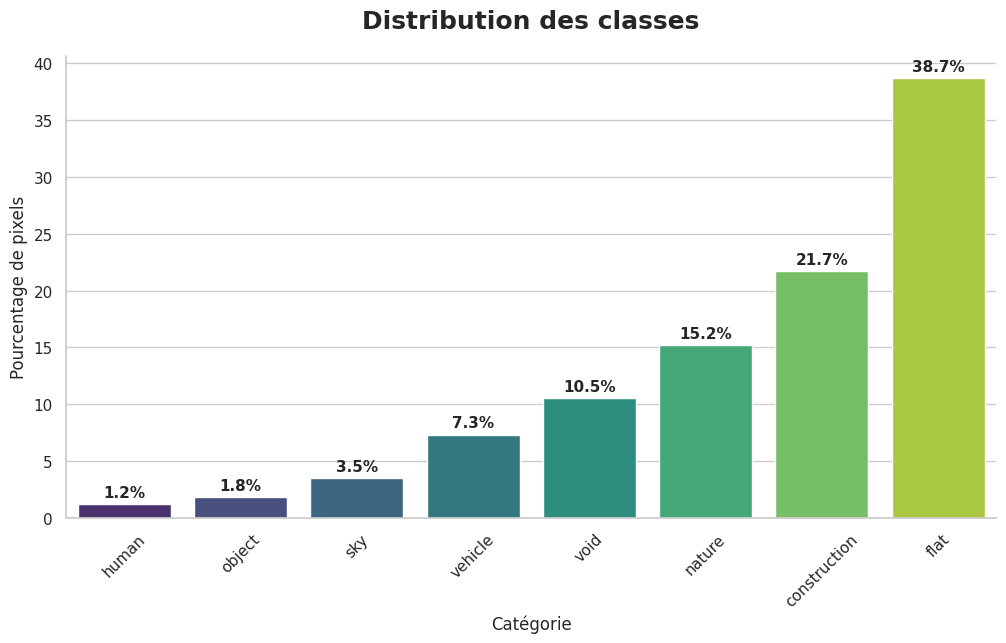

In [22]:
import seaborn as sns
import polars as pl

catg_dict = {row[3]:row[2] for row in LABELS}
catg_name = [catg_dict[i] for i in range(len(catg_dict))]

df_distrib = pl.DataFrame({
	'Classe': catg_name,
	'Pourcentage': prct_pxl_count
})

df_distrib = df_distrib.sort('Pourcentage')

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
	data=df_distrib, 
	x='Classe',
	y='Pourcentage',
	palette="viridis",
	hue='Classe',
	legend=False
)

for i in ax.containers:
	ax.bar_label(i, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold') # type: ignore

plt.title("Distribution des classes", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Pourcentage de pixels", fontsize=12)
plt.xlabel("Catégorie", fontsize=12)
plt.xticks(rotation=45)
sns.despine()

plt.show()

Nous remarquons que certaines catégories sont beaucoup moins présentes que d'autres. Ceci peut représenter un problème, car notre modèle aura tendance à très rarement prédire nos données peu présente. De plus, ici ce sont les humains qui sont peu présent, et il serait dramatique de les confondres avec de la route. Pour pallier ce problème, nous pourrons ajouter des poids lors de notre entraînement pour que les erreurs faites sur la mauvaise interprétation d'humains et d'objet soit grave, et que donc notre modèle est moins tendance à faire cette erreur.

### Réduction des labels

Nous avons appris dans la description des données qu'il y avaient 35 labels en tout ranger dans 8 catégories. Le système de décision n'aura besoin que des 8 catégories, nous pouvons donc réduire la taille des labels possibles, ce qui va nous permettre d'accélerer la vitesse du modèle et lui permettra de mieux généraliser et donc de mieux performer.

In [23]:
cat_mask = MAPPING_ARRAY[mask]

print(np.unique(mask))
print(np.unique(cat_mask))

[ 1  3  4  6  7  8  9 11 12 17 19 20 21 23 24 26 32]
[0 1 2 3 4 5 6 7]


Visualisons cette différence en affichant l'image de base et nos masques.

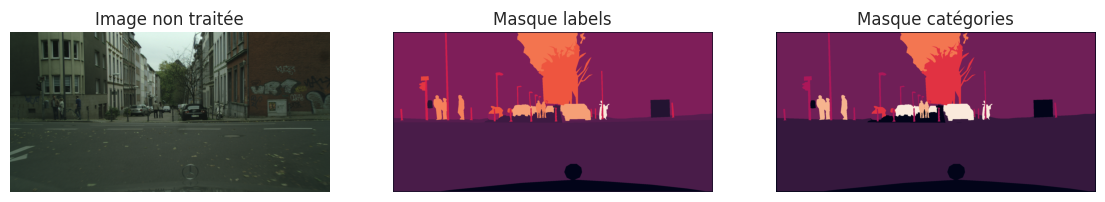

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))
for ax in axs:
	ax.axis("off")

axs[0].imshow(img)
axs[0].set_title("Image non traitée")

axs[1].imshow(mask)
axs[1].set_title("Masque labels")

axs[2].imshow(cat_mask	)
axs[2].set_title("Masque catégories")

plt.show()

C'est subtile, mais on peut voir par exemple que le scooter à droite de l'image est affiché d'une couleur différente dans le masque avec les labels, alors qu'il est de la même couleur dans le masque avec seulement les catégories.

## Mise en place du modèle

Maintenant que nous en savons plus sur nos images que la méthode pour passer des labels aux catégories est clair, nous pouvons mettre en place les ressources nécessaires à l'entraînement de notre modèle.

### Classe "Dataset"

Commençons par l'héritance de la classe "Dataset" qui nour permettra de charger les images pour notre modèle.

In [25]:
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2

size_divider = 4
img_resize = (int(img.shape[0] / size_divider), int(img.shape[1] / size_divider))

img_transformer = v2.Compose([
	v2.Resize(img_resize, interpolation=v2.InterpolationMode.BILINEAR),
	v2.ToImage(),
	v2.ToDtype(torch.float32, scale=True),
	v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transformer = v2.Compose([
	v2.Resize(img_resize, interpolation=v2.InterpolationMode.NEAREST),
	v2.ToImage(),
	v2.ToDtype(torch.long)
])

class ImagesDataset(Dataset):
	
	def __init__(self, imgs_base_folder, folder_type, mapping_array, img_transformer, mask_transformer):

		self.imgs_folder = imgs_base_folder + "/" + folder_type + "/*/*"

		self.imgs_path = []
		for img_path in glob.glob(self.imgs_folder):
			self.imgs_path.append(img_path)
		
		self.mapping_array = torch.tensor(mapping_array, dtype=torch.long)
		self.img_transformer = img_transformer
		self.mask_transformer = mask_transformer
		
	def __len__ (self):
		return len(self.imgs_path)
		
	def __getitem__ (self, index):
		
		img_path = self.imgs_path[index]
		mask_path = img_path.replace("leftImg8bit", "gtFine")
		mask_path = mask_path.replace(".png", "_labelIds.png")

		img = Image.open(img_path)
		mask = Image.open(mask_path)

		img_tensor = self.img_transformer(img)
		mask_tensor = self.mask_transformer(mask).squeeze(0)

		mask_tensor = self.mapping_array[mask_tensor]

		return(img_tensor, mask_tensor)

Testons avec une image pour être sûr qu'il n'y ait pas d'erreur.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 256, 512])
torch.Size([256, 512])
tensor([0, 1, 2, 3, 4, 5, 6, 7])


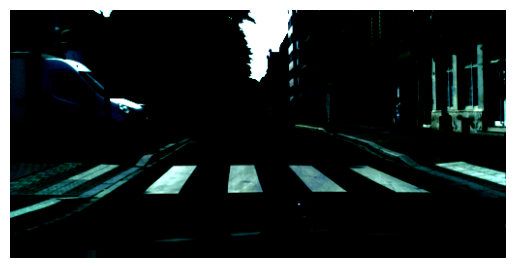

In [26]:
folder_path = "data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit"
test_tuple = ImagesDataset(folder_path, "train", MAPPING_ARRAY, img_transformer, mask_transformer)

test_img, test_mask = test_tuple[0]
print(test_img.shape)
print(test_mask.shape)
print(test_mask.unique())

plt.imshow(test_img.permute(1, 2, 0))
plt.axis(False)
plt.show()

### Classe pour l'entraînement

Maintenant passons au "dataloader". Cette classe va nous permettre d'aller chercher des données chargées via la classe précédente, et les transmettre à notre modèle.

In [9]:
from torch.utils.data import DataLoader

def get_dataloaders(img_resize, batch_size, num_workers):
	
	transform_img = v2.Compose([
		v2.Resize(img_resize, interpolation=v2.InterpolationMode.BILINEAR),
		v2.ToImage(),
		v2.ToDtype(torch.float32, scale=True),
		v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
	])

	transform_mask = v2.Compose([
		v2.Resize(img_resize, interpolation=v2.InterpolationMode.NEAREST),
		v2.ToImage(),
		v2.ToDtype(torch.long)
	])

	train_ds = ImagesDataset(folder_path, "train", MAPPING_ARRAY, transform_img, transform_mask)
	val_ds = ImagesDataset(folder_path, "val", MAPPING_ARRAY, transform_img, transform_mask)

	train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
	val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

	return train_loader, val_loader

In [10]:
def compute_iou_dice(preds, targets, num_classes, smooth=1e-6):

	iou_per_class = []
	dice_per_class = []

	for cls in range(num_classes):
		pred_inds = (preds == cls)
		target_inds = (targets == cls)

		intersection = (pred_inds & target_inds).float().sum()
		union = (pred_inds | target_inds).float().sum()
		total_area = pred_inds.float().sum() + target_inds.float().sum()

		iou = (intersection + smooth) / (union + smooth)
		dice = (2 * intersection + smooth) / (total_area + smooth)

		iou_per_class.append(iou)
		dice_per_class.append(dice)

	return torch.stack(iou_per_class).mean().item(), torch.stack(dice_per_class).mean().item(), iou_per_class

In [11]:
import mlflow

def log_mask_prediction(model, dataloader, device, epoch):
	
	model.eval()

	dl_iterator = iter(dataloader)
	imgs, targets = next(dl_iterator)
	imgs = imgs.to(device)
	count = 0
	index = 0
	no_humans_objects = True
	while no_humans_objects:
		try:
			target_pxls = np.unique(targets[index], return_counts=True)
			pxls_count = {index:count for index, count in zip(target_pxls[0], target_pxls[1])}
			if 3 in pxls_count.keys() and 6 in pxls_count.keys():
				if pxls_count[3] > 10000 and pxls_count[6] > 10000:
					no_humans_objects = False
			index += 1
		except IndexError:
			imgs, targets = next(dl_iterator)
			count += 1
			imgs = imgs.to(device)
			index = 0

	with torch.no_grad():
		outputs = model(imgs)
		preds = torch.argmax(outputs, dim=1)

	img_display = imgs[index].cpu().permute(1, 2, 0).numpy()
	mean = np.array([0.485, 0.456, 0.406])
	std = np.array([0.229, 0.224, 0.225])
	img_display = std * img_display + mean
	img_display = np.clip(img_display, 0, 1)

	target_mask = targets[index].cpu().numpy()
	pred_mask = preds[index].cpu().numpy()

	fig, ax = plt.subplots(1, 3, figsize=(15, 5))

	CITYSCAPES_PALETTE = np.array([
		[0, 0, 0],
		[128, 64, 128],
		[70, 70, 70],
		[220, 220, 0],
		[107, 142, 35],
		[70, 130, 180],
		[220, 20, 60],
		[0, 0, 142],
	])

	target_mask = CITYSCAPES_PALETTE[target_mask]
	pred_mask = CITYSCAPES_PALETTE[pred_mask]

	ax[0].imshow(img_display)
	ax[0].set_title("Image originale")
	ax[0].axis("off")
	
	ax[1].imshow(target_mask)
	ax[1].set_title("Masque originale")
	ax[1].axis("off")
	
	ax[2].imshow(pred_mask)
	ax[2].set_title(f"Masque prédit à l'époque {epoch + 1}")
	ax[2].axis("off")

	mlflow.log_figure(fig, f"visual_check_epoch_{epoch + 1}.png")
	plt.close(fig)

/home/titouan/Documents/Open Classrooms/Projets/p8/IAEngP8/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
def fit_engine(model, train_loader, val_loader, optimizer, criterion, epochs, device):

	CLASS_NAMES = ['Void', 'Flat', 'Construction', 'Object', 'Nature', 'Sky', 'Human', 'Vehicle']

	history = []

	for epoch in range(epochs):

		model.train()
		train_loss = 0.0
		for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
			imgs, targets = imgs.to(device), targets.to(device)
			
			optimizer.zero_grad()
			outputs = model(imgs)
			loss = criterion(outputs, targets)
			loss.backward()
			optimizer.step()

			train_loss += loss.item()

		avg_train_loss = train_loss / len(train_loader)

		model.eval()
		val_loss = 0.0
		total_iou = 0.0
		total_dice = 0.0
		total_batches = 0

		correct_pixels = 0
		total_pixels = 0

		total_iou_per_class = torch.zeros(8).to(device)
		
		with torch.no_grad():
			for imgs, targets in val_loader:
				imgs, targets = imgs.to(device), targets.to(device)
				outputs = model(imgs)
				loss = criterion(outputs, targets)
				val_loss += loss.item()
				
				preds = torch.argmax(outputs, dim=1)
				correct_pixels += (preds == targets).sum().item()
				total_pixels += targets.numel()
				val_iou, val_dice, iou_per_class = compute_iou_dice(preds, targets, 8)

				total_iou += val_iou
				total_dice += val_dice

				total_iou_per_class += torch.stack(iou_per_class).to(device)
				total_batches += 1

		avg_val_loss = val_loss / total_batches
		avg_iou = total_iou / total_batches
		avg_dice = total_dice / total_batches
		val_accuracy = correct_pixels / total_pixels * 100
		avg_iou_per_class = total_iou_per_class / total_batches

		mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
		mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
		mlflow.log_metric("val_iou", avg_iou, step=epoch)
		mlflow.log_metric("val_dice", avg_dice, step=epoch)
		
		for i, class_name in enumerate(CLASS_NAMES):
			metric_name = f"IoU_Class_{class_name}"
			score = avg_iou_per_class[i].item()
			mlflow.log_metric(metric_name, score, step=epoch)
		
		print(f"Epoch: {epoch +1} | 📉 Loss: {avg_val_loss:.4f} | ✅ Accuracy: {val_accuracy:.2f}% | IoU: {avg_iou:.4f} | Dice: {avg_dice:.4f}")
		log_mask_prediction(model, val_loader, device, epoch)

	return history

In [13]:
from torch import nn
from torch import optim
import segmentation_models_pytorch as smp
import gc

if torch.cuda.is_available():
	device = "cuda"
else:
	device = "cpu"

lr = 1e-4
NUM_WORKERS = 4
resize_batch_pair = [(1, 2), (2, 8), (4, 32), (8, 128)]

tracking_uri = "file:./outputs/mlruns"
mlflow.set_tracking_uri(tracking_uri)

mlflow.set_experiment("Cityscapes_Experiments")

def run_size_study(resize_list, lr, device):

	with mlflow.start_run(run_name="Study_Image_Resizing") as parent_run:
		mlflow.log_param("description", "Test de l'impact de la résolution sur l'IoU")
		mlflow.log_param("gpu", torch.cuda.get_device_name(0))
		
		print(f"📂 Étude lancée : {parent_run.info.run_id}")

		for pair in resize_list:
			div, batch_size = pair
			img_resize = (int(1024 / div), int(2048 / div))
			
			run_name = f"Size_{img_resize[0]}x{img_resize[1]}"
			
			with mlflow.start_run(run_name=run_name, nested=True):
				
				print(f"\n🚀 Start Child: {run_name} | Batch: {batch_size}")
				
				mlflow.log_params({
					"img_h": img_resize[0], 
					"img_w": img_resize[1],
					"batch_size": batch_size,
					"lr": lr
				})
				
				train_dl, val_dl = get_dataloaders(img_resize, batch_size, NUM_WORKERS)
				
				model = smp.Unet("resnet34", encoder_weights="imagenet", classes=8).to(device)
				my_weigths = 1 / np.log(1.02 + prct_pxl_count / 100)
				criterion = nn.CrossEntropyLoss(weight=torch.tensor(my_weigths, dtype=torch.float32).to(device))
				optimizer = optim.Adam(model.parameters(), lr=lr)
			
				fit_engine(model, train_dl, val_dl, optimizer, criterion, epochs=5, device=device)

				del model, optimizer, train_dl, val_dl
				gc.collect()
				torch.cuda.empty_cache()

# run_size_study(resize_batch_pair, lr=1e-4, device=device)

/home/titouan/Documents/Open Classrooms/Projets/p8/IAEngP8/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


In [14]:

def run_encoder_study(encoder_list, lr, device):

	BASE_BATCH_SIZE = 8
	batch_size = BASE_BATCH_SIZE
	IMG_RESIZE = (int(1024 / 2), int(2048 / 2))

	with mlflow.start_run(run_name="Study_Encoder") as parent_run:
		mlflow.log_param("description", "Test des encodeurs")
		mlflow.log_param("gpu", torch.cuda.get_device_name(0))
		
		print(f"📂 Étude lancée : {parent_run.info.run_id}")

		for encoder_name in encoder_list:
			
			run_name = f"Model_{encoder_name}"
			success = False
			while batch_size >= 1 and not success:
				try:
					with mlflow.start_run(run_name=run_name, nested=True):
						
						print(f"\n🚀 Start Child: {run_name} | Batch: {batch_size}")
						
						mlflow.log_params({
							"img_h": IMG_RESIZE[0], 
							"img_w": IMG_RESIZE[1],
							"batch_size": batch_size,
							"lr": lr,
							"model": encoder_name
						})
						
						train_dl, val_dl = get_dataloaders(IMG_RESIZE, batch_size, NUM_WORKERS)
						
						model = smp.Unet(f"{encoder_name}", encoder_weights="imagenet", classes=8).to(device)
						my_weigths = 1 / np.log(1.02 + prct_pxl_count / 100)
						criterion = nn.CrossEntropyLoss(weight=torch.tensor(my_weigths, dtype=torch.float32).to(device))
						optimizer = optim.Adam(model.parameters(), lr=lr)
						
						fit_engine(model, train_dl, val_dl, optimizer, criterion, epochs=5, device=device)

						del model, optimizer, train_dl, val_dl
						gc.collect()
						torch.cuda.empty_cache()
						batch_size = BASE_BATCH_SIZE
						success = True
				except RuntimeError:
					
					print(f"Echec avec batch_size={batch_size}. On réessaie avec {batch_size // 2}")
					batch_size //= 2

encoder_to_test = ["resnet34", "efficientnet-b0", "mobilenet_v2"]
# run_encoder_study(encoder_to_test, lr=1e-4, device=device)

In [15]:
def run_encoder_study(weights_multiplier, device):

	BASE_BATCH_SIZE = 4
	LR = 1e-4
	batch_size = BASE_BATCH_SIZE
	IMG_RESIZE = (int(1024 / 2), int(2048 / 2))

	with mlflow.start_run(run_name="Study_Weigths_reduction") as parent_run:
		mlflow.log_param("description", "Test des poids personalisé")
		mlflow.log_param("gpu", torch.cuda.get_device_name(0))
		
		print(f"📂 Étude lancée : {parent_run.info.run_id}")

		for multiplier in weights_multiplier:
			
			run_name = f"Multiplication du poids des humains et objets : {multiplier}"
			success = False
			while batch_size >= 1 and not success:
				try:
					with mlflow.start_run(run_name=run_name, nested=True):
						
						print(f"\n🚀 Start Child: {run_name} | Batch: {batch_size}")
						
						mlflow.log_params({
							"img_h": IMG_RESIZE[0], 
							"img_w": IMG_RESIZE[1],
							"batch_size": batch_size,
							"lr": LR,
							"model": "mobilenet_v2",
							"multiplier" : multiplier
						})
						
						train_dl, val_dl = get_dataloaders(IMG_RESIZE, batch_size, NUM_WORKERS)
						
						model = smp.Unet("mobilenet_v2", encoder_weights="imagenet", classes=8).to(device)
						my_weigths = 1 / np.log(1.02 + prct_pxl_count / 100)
						my_weigths[3] *= multiplier
						my_weigths[6] *= multiplier
						print(my_weigths)
						if multiplier:
							criterion = nn.CrossEntropyLoss(weight=torch.tensor(my_weigths, dtype=torch.float32).to(device))
						else:
							criterion = nn.CrossEntropyLoss()

						optimizer = optim.Adam(model.parameters(), lr=LR)
						
						fit_engine(model, train_dl, val_dl, optimizer, criterion, epochs=5, device=device)

						del model, optimizer, train_dl, val_dl
						gc.collect()
						torch.cuda.empty_cache()
						batch_size = BASE_BATCH_SIZE
						success = True

				except RuntimeError:
					print(f"Echec avec batch_size={batch_size}. On réessaie avec {batch_size // 2}")
					batch_size //= 2

weights_multiplier = [1, 0.8, 0.5, 0]
# run_encoder_study(weights_multiplier, device=device)

In [16]:
def run_encoder_study(device):

	BASE_BATCH_SIZE = 8
	LR = 1e-4
	batch_size = BASE_BATCH_SIZE
	IMG_RESIZE = (512, 1024)

	with mlflow.start_run(run_name="Big_epochs"):
		mlflow.log_param("description", "Entrainement avec grosse epochs")
		mlflow.log_param("gpu", torch.cuda.get_device_name(0))
		
		success = False
		while batch_size >= 1 and not success:

			try:
				print(f"\n🚀 Batch: {batch_size}")

				train_dl, val_dl = get_dataloaders(IMG_RESIZE, batch_size, NUM_WORKERS)
				
				model = smp.Unet("mobilenet_v2", encoder_weights="imagenet", classes=8).to(device)
				criterion = nn.CrossEntropyLoss()
				optimizer = optim.Adam(model.parameters(), lr=LR)
				
				fit_engine(model, train_dl, val_dl, optimizer, criterion, epochs=20, device=device)
				
				mlflow.log_params({
					"img_h": IMG_RESIZE[0], 
					"img_w": IMG_RESIZE[1],
					"batch_size": batch_size,
					"lr": LR,
					"model": "mobilenet_v2"
				})
				
				save_dir = "./outputs/models"
				os.makedirs(save_dir, exist_ok=True)
				model_filepath = os.path.join(save_dir, "cityscapes_mobilenet_v2_final.pth")
				torch.save(model.state_dict(), model_filepath)

				mlflow.log_artifact(model_filepath, artifact_path="models")
				print(f"Modèle sauvegardé sous le nom : {model_filepath}")

				del model, optimizer, train_dl, val_dl
				gc.collect()
				torch.cuda.empty_cache()
				batch_size = BASE_BATCH_SIZE
				success = True

			except RuntimeError:
				print(f"Echec avec batch_size={batch_size}. On réessaie avec {batch_size // 2}")
				batch_size //= 2
				torch.cuda.empty_cache()

# run_encoder_study(device)

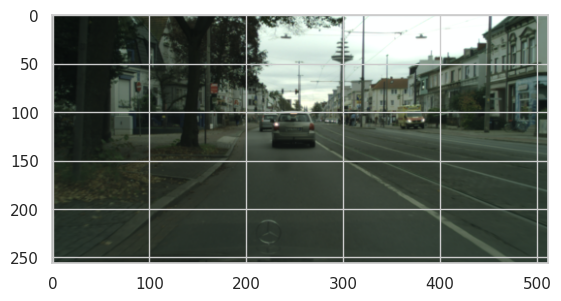

In [17]:
import albumentations as albu

class ImagesDatasetDataAugment(Dataset):
	
	def __init__(self, imgs_base_folder, folder_type, mapping_array, img_transformer, mask_transformer, data_augment_pipeline):

		self.imgs_folder = imgs_base_folder + "/" + folder_type + "/*/*"

		self.imgs_path = []
		for img_path in glob.glob(self.imgs_folder):
			self.imgs_path.append(img_path)
		
		self.mapping_array = torch.tensor(mapping_array, dtype=torch.long)
		self.img_transformer = img_transformer
		self.mask_transformer = mask_transformer
		self.data_augment = data_augment_pipeline
		self.folder_type = folder_type
		
	def __len__ (self):
		return len(self.imgs_path)
		
	def __getitem__ (self, index):
		
		img_path = self.imgs_path[index]
		mask_path = img_path.replace("leftImg8bit", "gtFine")
		mask_path = mask_path.replace(".png", "_labelIds.png")

		img = Image.open(img_path)
		mask = Image.open(mask_path)
		img_array, mask_array = np.array(img), np.array(mask)
	
		if self.folder_type == "train":
			augmented = self.data_augment(image=img_array, mask=mask_array)
			image_augmented = augmented["image"]
			mask_augmented = augmented["mask"]
		else:
			image_augmented, mask_augmented = img_array, mask_array

		img_tensor = self.img_transformer(image_augmented)
		mask_tensor = self.mask_transformer(mask_augmented).squeeze(0)

		mask_tensor = self.mapping_array[mask_tensor]

		return(img_tensor, mask_tensor)

def get_dataloaders_augment(img_resize, batch_size, num_workers):
	
	data_augmentation_pipeline = albu.Compose([
		albu.HorizontalFlip(p=0.5),
		albu.RandomBrightnessContrast(p=0.2),
		albu.GaussianBlur(blur_limit=(3, 5), p=0.2)
	])

	transform_img = v2.Compose([
		v2.ToImage(),
		v2.Resize(img_resize, interpolation=v2.InterpolationMode.BILINEAR),
		v2.ToDtype(torch.float32, scale=True),
		v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
	])

	transform_mask = v2.Compose([
		v2.ToImage(),
		v2.Resize(img_resize, interpolation=v2.InterpolationMode.NEAREST),
		v2.ToDtype(torch.long)
	])

	train_ds = ImagesDatasetDataAugment(folder_path, "train", MAPPING_ARRAY, transform_img, transform_mask, data_augmentation_pipeline)
	val_ds = ImagesDatasetDataAugment(folder_path, "val", MAPPING_ARRAY, transform_img, transform_mask, data_augmentation_pipeline)

	train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
	val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

	return train_loader, val_loader

train_loader, val_loader = get_dataloaders_augment(img_resize, 1, NUM_WORKERS)

img_display = next(iter(train_loader))[0][0].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

plt.imshow(img_display)
del train_loader, val_loader

In [18]:
def run_encoder_study(device):

	BASE_BATCH_SIZE = 4
	LR = 1e-4
	batch_size = BASE_BATCH_SIZE
	IMG_RESIZE = (512, 1024)

	with mlflow.start_run(run_name="Data_augmentation"):
		mlflow.log_param("description", "Entrainement en utilisant de la data augmentation")
		mlflow.log_param("gpu", torch.cuda.get_device_name(0))
		
		success = False
		while batch_size >= 1 and not success:

			try:
				print(f"\n🚀 Batch: {batch_size}")

				train_dl, val_dl = get_dataloaders_augment(IMG_RESIZE, batch_size, NUM_WORKERS)
				
				model = smp.Unet("mobilenet_v2", encoder_weights="imagenet", classes=8).to(device)
				criterion = nn.CrossEntropyLoss()
				optimizer = optim.Adam(model.parameters(), lr=LR)
				
				fit_engine(model, train_dl, val_dl, optimizer, criterion, epochs=20, device=device)
				
				mlflow.log_params({
					"img_h": IMG_RESIZE[0], 
					"img_w": IMG_RESIZE[1],
					"batch_size": batch_size,
					"lr": LR,
					"model": "mobilenet_v2"
				})
				
				save_dir = "./outputs/models"
				os.makedirs(save_dir, exist_ok=True)
				model_filepath = os.path.join(save_dir, "cityscapes_mobilenet_v2_data_augmentation.pth")
				torch.save(model.state_dict(), model_filepath)

				mlflow.log_artifact(model_filepath, artifact_path="models")
				print(f"Modèle sauvegardé sous le nom : {model_filepath}")

				del model, optimizer, train_dl, val_dl
				gc.collect()
				torch.cuda.empty_cache()
				batch_size = BASE_BATCH_SIZE
				success = True

			except RuntimeError:
				print(f"Echec avec batch_size={batch_size}. On réessaie avec {batch_size // 2}")
				batch_size //= 2

				torch.cuda.empty_cache()

# run_encoder_study(device)